# Major Project: Seasonal Agriculture Performance Analysis

## Project objective
Analyze agricultural data across **Kharif, Rabi and Zaid** seasons to identify meaningful patterns, trends, relationships and variations in agricultural performance.

The project brief requires:
- dataset exploration and understanding
- data cleaning and preparation
- seasonal performance comparison
- investigation of environmental/resource relationships
- group comparisons and unusual-pattern detection
- statistical and visualization techniques
- evidence-based conclusions and recommendations

This notebook performs those operations reproducibly.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print("Shape:", df.shape)
display(df.head())
display(df.dtypes)
display(df.isna().sum())

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


## 1. Data quality checks

In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm_IDs:", df["Farm_ID"].duplicated().sum())

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

display(df.describe(include="all").T)

Duplicate rows: 0
Duplicate Farm_IDs: 0


,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


### Cleaning approach
Only three analytical variables contain missing values: `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha`. Because the project focuses on seasonal and crop differences, missing numeric values are imputed using the **Season + Crop median**, with the overall median as a fallback. Extreme values are flagged using the IQR rule rather than automatically deleted, since crop types such as sugarcane naturally operate on a different yield scale.

In [ ]:
clean = df.copy()

for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    group_median = clean.groupby(["Season", "Crop"])[col].transform("median")
    clean[col] = clean[col].fillna(group_median)
    clean[col] = clean[col].fillna(clean[col].median())

clean["Profit_Margin_pct"] = clean["Profit_INR"] / clean["Revenue_INR"] * 100
clean["Positive_Profit"] = np.where(clean["Profit_INR"] > 0, "Yes", "No")

for col in ["Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR", "Water_Efficiency_t_per_1000m3"]:
    q1, q3 = clean[col].quantile([.25, .75])
    iqr = q3 - q1
    clean[f"{col}_Outlier"] = (clean[col] < q1 - 1.5*iqr) | (clean[col] > q3 + 1.5*iqr)

display(clean.isna().sum()[clean.isna().sum() > 0])

,0


## 2. Seasonal performance analysis

In [ ]:
season = clean.groupby("Season").agg(
    Farms=("Farm_ID","size"),
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Median_Yield=("Yield_Tonnes_Ha","median"),
    Avg_Profit=("Profit_INR","mean"),
    Median_Profit=("Profit_INR","median"),
    Positive_Profit_pct=("Profit_INR", lambda x: (x > 0).mean()*100),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct","mean"),
    Avg_Rainfall=("Rainfall_mm","mean"),
    Avg_Temperature=("Avg_Temperature_C","mean"),
    Avg_Humidity=("Humidity_pct","mean")
).round(2)

display(season)

,Farms,Avg_Yield,Median_Yield,Avg_Profit,Median_Profit,Positive_Profit_pct,Avg_Water_Efficiency,Avg_Disease_Risk,Avg_Rainfall,Avg_Temperature,Avg_Humidity
Season,,,,,,,,,,,
Kharif,1779,5.63,1.95,178914.65,38808.0,57.79,5.89,54.47,852.10,28.45,71.81
Rabi,1627,5.09,1.66,87689.47,-3187.0,48.86,5.19,40.48,435.95,23.49,57.89
Zaid,594,4.64,1.45,-24804.82,-62144.0,35.52,4.41,38.22,299.16,31.04,52.01


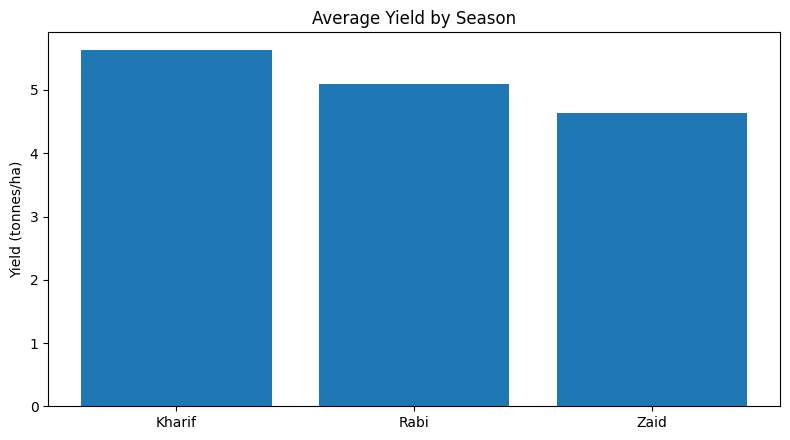

In [ ]:
fig, ax = plt.subplots(figsize=(8,4.5))
ax.bar(season.index, season["Avg_Yield"])
ax.set_title("Average Yield by Season")
ax.set_ylabel("Yield (tonnes/ha)")
plt.tight_layout()

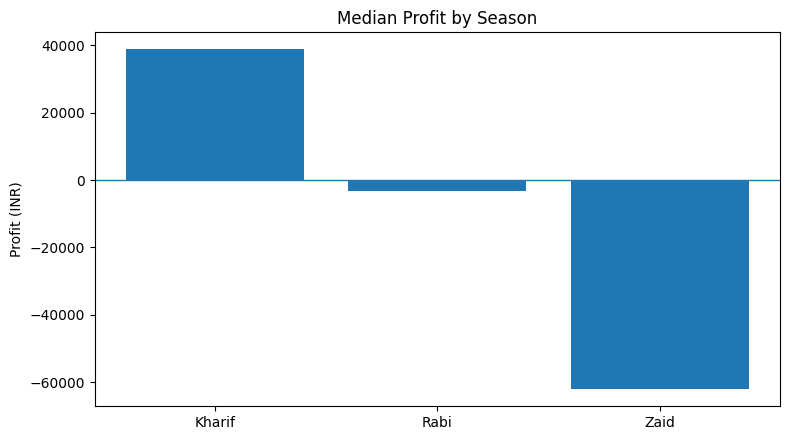

In [ ]:
fig, ax = plt.subplots(figsize=(8,4.5))
ax.bar(season.index, season["Median_Profit"])
ax.axhline(0, linewidth=1)
ax.set_title("Median Profit by Season")
ax.set_ylabel("Profit (INR)")
plt.tight_layout()

## 3. Crop and irrigation comparisons

In [ ]:
crop = clean.groupby(["Season","Crop"]).agg(
    Farms=("Farm_ID","size"),
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Median_Yield=("Yield_Tonnes_Ha","median"),
    Avg_Profit=("Profit_INR","mean"),
    Median_Profit=("Profit_INR","median"),
    Positive_Profit_pct=("Profit_INR", lambda x: (x > 0).mean()*100),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean")
).reset_index().round(2)

display(crop.sort_values(["Season","Median_Profit"], ascending=[True,False]))

,Season,Crop,Farms,Avg_Yield,Median_Yield,Avg_Profit,Median_Profit,Positive_Profit_pct,Avg_Water_Efficiency
6,Kharif,Sugarcane,125,53.46,56.65,1000790.81,940895.0,92.00,36.00
0,Kharif,Chilli,185,1.73,1.78,954380.42,705116.0,85.41,3.26
1,Kharif,Cotton,215,1.37,1.44,216999.55,136193.0,72.09,2.13
2,Kharif,Groundnut,193,1.48,1.52,108265.44,87406.0,66.84,3.58
4,Kharif,Pulses,221,1.04,1.09,43338.90,57156.0,62.90,3.35
3,Kharif,Maize,234,2.97,3.12,-39332.67,-9883.5,46.58,6.05
5,Kharif,Rice,314,2.71,2.88,-64903.40,-39903.5,41.40,2.17
7,Kharif,Wheat,292,2.26,2.36,-105871.87,-57248.5,31.85,4.76
14,Rabi,Sugarcane,129,43.96,45.46,731612.86,622229.0,85.27,27.92
8,Rabi,Chilli,163,1.46,1.56,638572.50,470004.0,78.53,2.89


In [ ]:
irrigation = clean.groupby("Irrigation_Method").agg(
    Farms=("Farm_ID","size"),
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Median_Yield=("Yield_Tonnes_Ha","median"),
    Avg_Profit=("Profit_INR","mean"),
    Positive_Profit_pct=("Profit_INR", lambda x: (x > 0).mean()*100),
    Avg_Water_Used=("Water_Used_m3","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean")
).sort_values("Avg_Profit", ascending=False).round(2)

display(irrigation)

,Farms,Avg_Yield,Median_Yield,Avg_Profit,Positive_Profit_pct,Avg_Water_Used,Avg_Water_Efficiency
Irrigation_Method,,,,,,,
Drip,915,6.67,1.96,219626.00,59.78,5918.75,6.27
Sprinkler,734,5.16,1.80,91121.08,51.91,6208.26,4.67
Rainfed,1041,4.60,1.72,79050.37,46.88,3549.55,7.56
Flood,1310,4.86,1.63,73354.02,47.18,8026.47,3.44


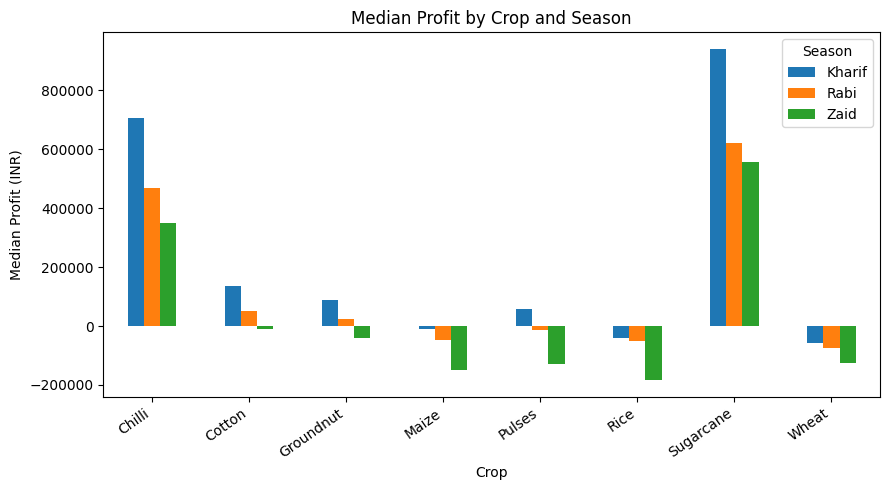

In [ ]:
pivot = crop.pivot(index="Crop", columns="Season", values="Median_Profit")
pivot.plot(kind="bar", figsize=(9,5))
plt.title("Median Profit by Crop and Season")
plt.ylabel("Median Profit (INR)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

## 4. Relationships and statistical testing

In [ ]:
numeric = clean.select_dtypes(include=np.number)
corr = numeric.corr()

print("Strongest correlations with Yield:")
display(corr["Yield_Tonnes_Ha"].sort_values(ascending=False).head(8))

print("Strongest correlations with Profit:")
display(corr["Profit_INR"].sort_values(ascending=False).head(8))

Strongest correlations with Yield:


,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.915517
Production_Tonnes,0.885442
Profit_INR,0.489350
Revenue_INR,0.433033
Water_Used_m3,0.387373
Profit_Margin_pct,0.205448
Nitrogen_kg_ha,0.053633


Strongest correlations with Profit:


,Profit_INR
Profit_INR,1.000000
Revenue_INR,0.887331
Production_Tonnes,0.554172
Water_Efficiency_t_per_1000m3,0.489487
Yield_Tonnes_Ha,0.489350
Profit_Margin_pct,0.481375
Market_Price_INR_Tonne,0.225119
Water_Used_m3,0.190278


In [ ]:
# Non-parametric tests are appropriate because profit/yield are strongly skewed
yield_groups = [clean.loc[clean["Season"]==s, "Yield_Tonnes_Ha"].dropna() for s in clean["Season"].unique()]
profit_groups = [clean.loc[clean["Season"]==s, "Profit_INR"].dropna() for s in clean["Season"].unique()]

print("Kruskal-Wallis yield:", stats.kruskal(*yield_groups))
print("Kruskal-Wallis profit:", stats.kruskal(*profit_groups))

Kruskal-Wallis yield: KruskalResult(statistic=np.float64(70.26461453711123), pvalue=np.float64(5.523734764890478e-16))
Kruskal-Wallis profit: KruskalResult(statistic=np.float64(101.92605491126021), pvalue=np.float64(7.362721866797111e-23))


## 5. Key evidence-based findings

1. **Kharif is the strongest overall season** in this dataset: it has the highest average yield, highest average and median profitability, and the highest positive-profit rate.
2. **Zaid is the weakest season financially**: its median profit is negative and its positive-profit rate is the lowest.
3. **Kharif has substantially higher rainfall and humidity**, while Zaid is warmer and drier. These are observed seasonal differences, not proof of causation.
4. **Sugarcane and chilli are the strongest profit-generating crops** across seasons by median profit, while wheat, rice and maize are frequently unprofitable in the dataset.
5. **Drip irrigation has the highest average yield and average profit among irrigation methods**, while rainfed farming has the highest water-efficiency metric. These results should be interpreted as associations because irrigation choice is not randomized.
6. Yield and water-efficiency are very strongly positively correlated in this dataset; this is partly expected because the water-efficiency metric itself contains yield in its definition.
7. Extreme values are present, especially for sugarcane yield/production and profit. They should be investigated rather than blindly removed.
8. The Kruskal-Wallis tests indicate statistically significant differences across seasons for both yield and profit (p-values < 0.001).

## 6. Recommendations

- Prioritize **season-specific planning** rather than treating all seasons identically.
- For lower-performing seasons, review crop selection, irrigation strategy, cost structure and market-price exposure.
- Promote **efficient irrigation practices** where agronomically suitable, with local feasibility checks.
- Use crop-season profitability as a planning metric alongside yield, because high yield does not automatically mean high profit.
- Investigate the extreme sugarcane observations separately before using the data for predictive modelling.
- For future work, add time-series information, input prices, crop-specific costs, market volatility and weather forecasts to improve decision support.

In [ ]:
# Save the cleaned dataset
clean.to_csv("seasonal_agriculture_performance_cleaned.csv", index=False)
print("Saved cleaned dataset:", clean.shape)

Saved cleaned dataset: (4000, 34)
